# Assignment 2 - Wine Data
Group Number 7
* Angelina Buysse
* Pranav Ramasahayam
* William Reimer
* Austin Rollfing
---
### Summary Of Results

i. Wine **DataFrame** shape: 178 x 14

ii. Data set shape: 178 x 13

iii. Target set shape: 178 x 1

iv. Strongest correlation with target:
1. 'flavanoids' (-0.847498)
2. 'od280/od315_of_diluted_wines' (-0.788230)
3. 'total_phenols' (-0.719163)

The K-Nearest Neighbors model implemented in this assignment performed very well. Using 33% of the dataset for testing, only a singular error was made by the classifier out of 59 predictions. 

The key performance metrics for the model are below, showing strong performance:
* Accuracy: 0.9831
* Precision: 0.9841
* Recall: 0.9861
* F1: 0.9848

---

First, all necessary libraries are imported.

In [433]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import seaborn as sns

The wine dataset is loaded and split into data (*X*), targets (*y*), and read as a *pandas* **DataFrame**.

In [434]:
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
frame = wine.frame

Next, an overview of the frame using **DataFrame.info()**.

In [435]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

Then, an overview of the data and target set, again using **DataFrame.info()**.

In [436]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [437]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: target
Non-Null Count  Dtype
--------------  -----
178 non-null    int64
dtypes: int64(1)
memory usage: 1.5 KB


**DataFrame.describe()** can be used to get min, max, mean, etc. for each feature.

In [438]:
frame.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


The frame can be split by the target class, and **DataFrame.describe()** can be used on each resulting frame to get the same statistics for each class.

In [439]:
target_0 = frame.loc[frame.target == 0]
target_1 = frame.loc[frame.target == 1]
target_2 = frame.loc[frame.target == 2]

In [440]:
target_0.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.0
mean,13.744746,2.010678,2.455593,17.037288,106.338983,2.840169,2.982373,0.290000,1.899322,5.528305,1.062034,3.157797,1115.711864,0.0
std,0.462125,0.688549,0.227166,2.546322,10.498949,0.338961,0.397494,0.070049,0.412109,1.238573,0.116483,0.357077,221.520767,0.0
min,12.850000,1.350000,2.040000,11.200000,89.000000,2.200000,2.190000,0.170000,1.250000,3.520000,0.820000,2.510000,680.000000,0.0
25%,13.400000,1.665000,2.295000,16.000000,98.000000,2.600000,2.680000,0.255000,1.640000,4.550000,0.995000,2.870000,987.500000,0.0
50%,13.750000,1.770000,2.440000,16.800000,104.000000,2.800000,2.980000,0.290000,1.870000,5.400000,1.070000,3.170000,1095.000000,0.0
75%,14.100000,1.935000,2.615000,18.700000,114.000000,3.000000,3.245000,0.320000,2.090000,6.225000,1.130000,3.420000,1280.000000,0.0
max,14.830000,4.040000,3.220000,25.000000,132.000000,3.880000,3.930000,0.500000,2.960000,8.900000,1.280000,4.000000,1680.000000,0.0


In [441]:
target_1.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.0
mean,12.278732,1.932676,2.244789,20.238028,94.549296,2.258873,2.080845,0.363662,1.630282,3.086620,1.056282,2.785352,519.507042,1.0
std,0.537964,1.015569,0.315467,3.349770,16.753497,0.545361,0.705701,0.123961,0.602068,0.924929,0.202937,0.496573,157.211220,0.0
min,11.030000,0.740000,1.360000,10.600000,70.000000,1.100000,0.570000,0.130000,0.410000,1.280000,0.690000,1.590000,278.000000,1.0
25%,11.915000,1.270000,2.000000,18.000000,85.500000,1.895000,1.605000,0.270000,1.350000,2.535000,0.925000,2.440000,406.500000,1.0
50%,12.290000,1.610000,2.240000,20.000000,88.000000,2.200000,2.030000,0.370000,1.610000,2.900000,1.040000,2.830000,495.000000,1.0
75%,12.515000,2.145000,2.420000,22.000000,99.500000,2.560000,2.475000,0.430000,1.885000,3.400000,1.205000,3.160000,625.000000,1.0
max,13.860000,5.800000,3.230000,30.000000,162.000000,3.520000,5.080000,0.660000,3.580000,6.000000,1.710000,3.690000,985.000000,1.0


In [442]:
target_2.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,48.000000,48.000000,48.0
mean,13.153750,3.333750,2.437083,21.416667,99.312500,1.678750,0.781458,0.44750,1.153542,7.396250,0.682708,1.683542,629.895833,2.0
std,0.530241,1.087906,0.184690,2.258161,10.890473,0.356971,0.293504,0.12414,0.408836,2.310942,0.114441,0.272111,115.097043,0.0
min,12.200000,1.240000,2.100000,17.500000,80.000000,0.980000,0.340000,0.17000,0.550000,3.850000,0.480000,1.270000,415.000000,2.0
25%,12.805000,2.587500,2.300000,20.000000,89.750000,1.407500,0.580000,0.39750,0.855000,5.437500,0.587500,1.510000,545.000000,2.0
50%,13.165000,3.265000,2.380000,21.000000,97.000000,1.635000,0.685000,0.47000,1.105000,7.550000,0.665000,1.660000,627.500000,2.0
75%,13.505000,3.957500,2.602500,23.000000,106.000000,1.807500,0.920000,0.53000,1.350000,9.225000,0.752500,1.820000,695.000000,2.0
max,14.340000,5.650000,2.860000,27.000000,123.000000,2.800000,1.570000,0.63000,2.700000,13.000000,0.960000,2.470000,880.000000,2.0


*pandas*' **scatter_matrix()** function can be used to visualize the correlations between each feature.

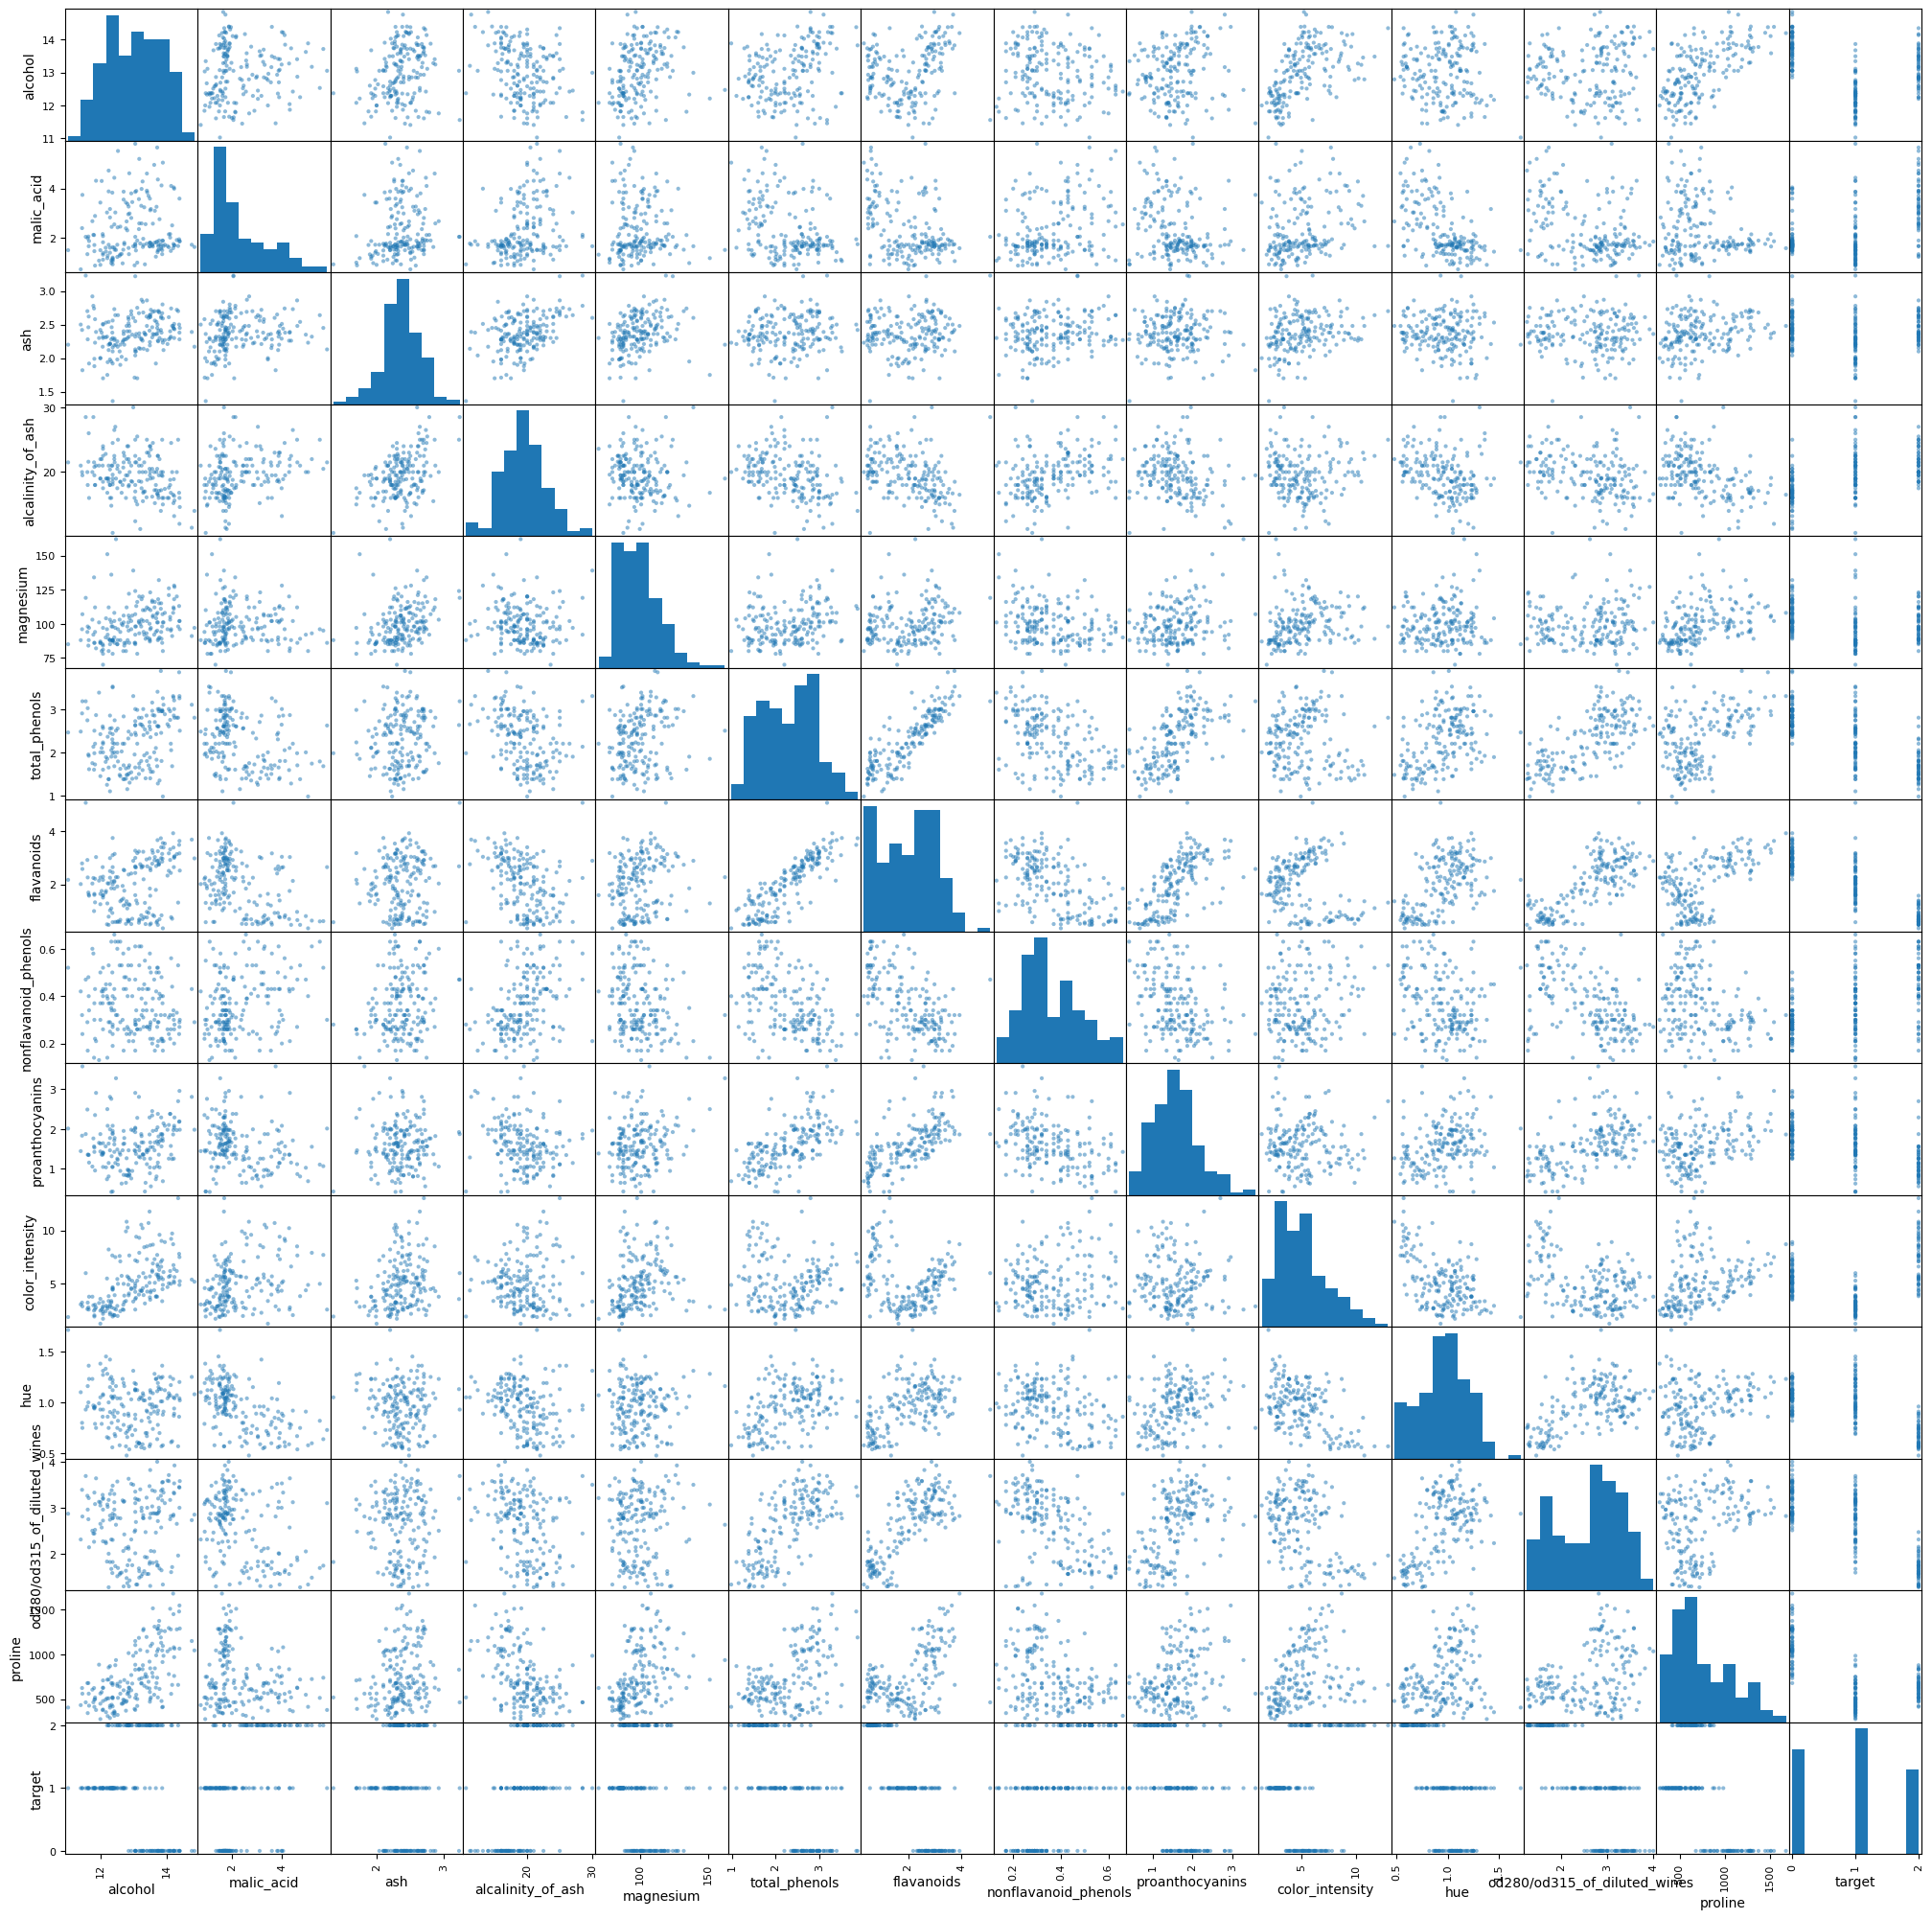

In [443]:
scatter_matrix_pd = pd.plotting.scatter_matrix(frame=frame, figsize=(25, 25))

An alternate scatter matrix can be made using *seaborn's* **pairplot()** function, where the color of each marker corresponds to the target class and the diagonal is the kernel density estimate for each target class.

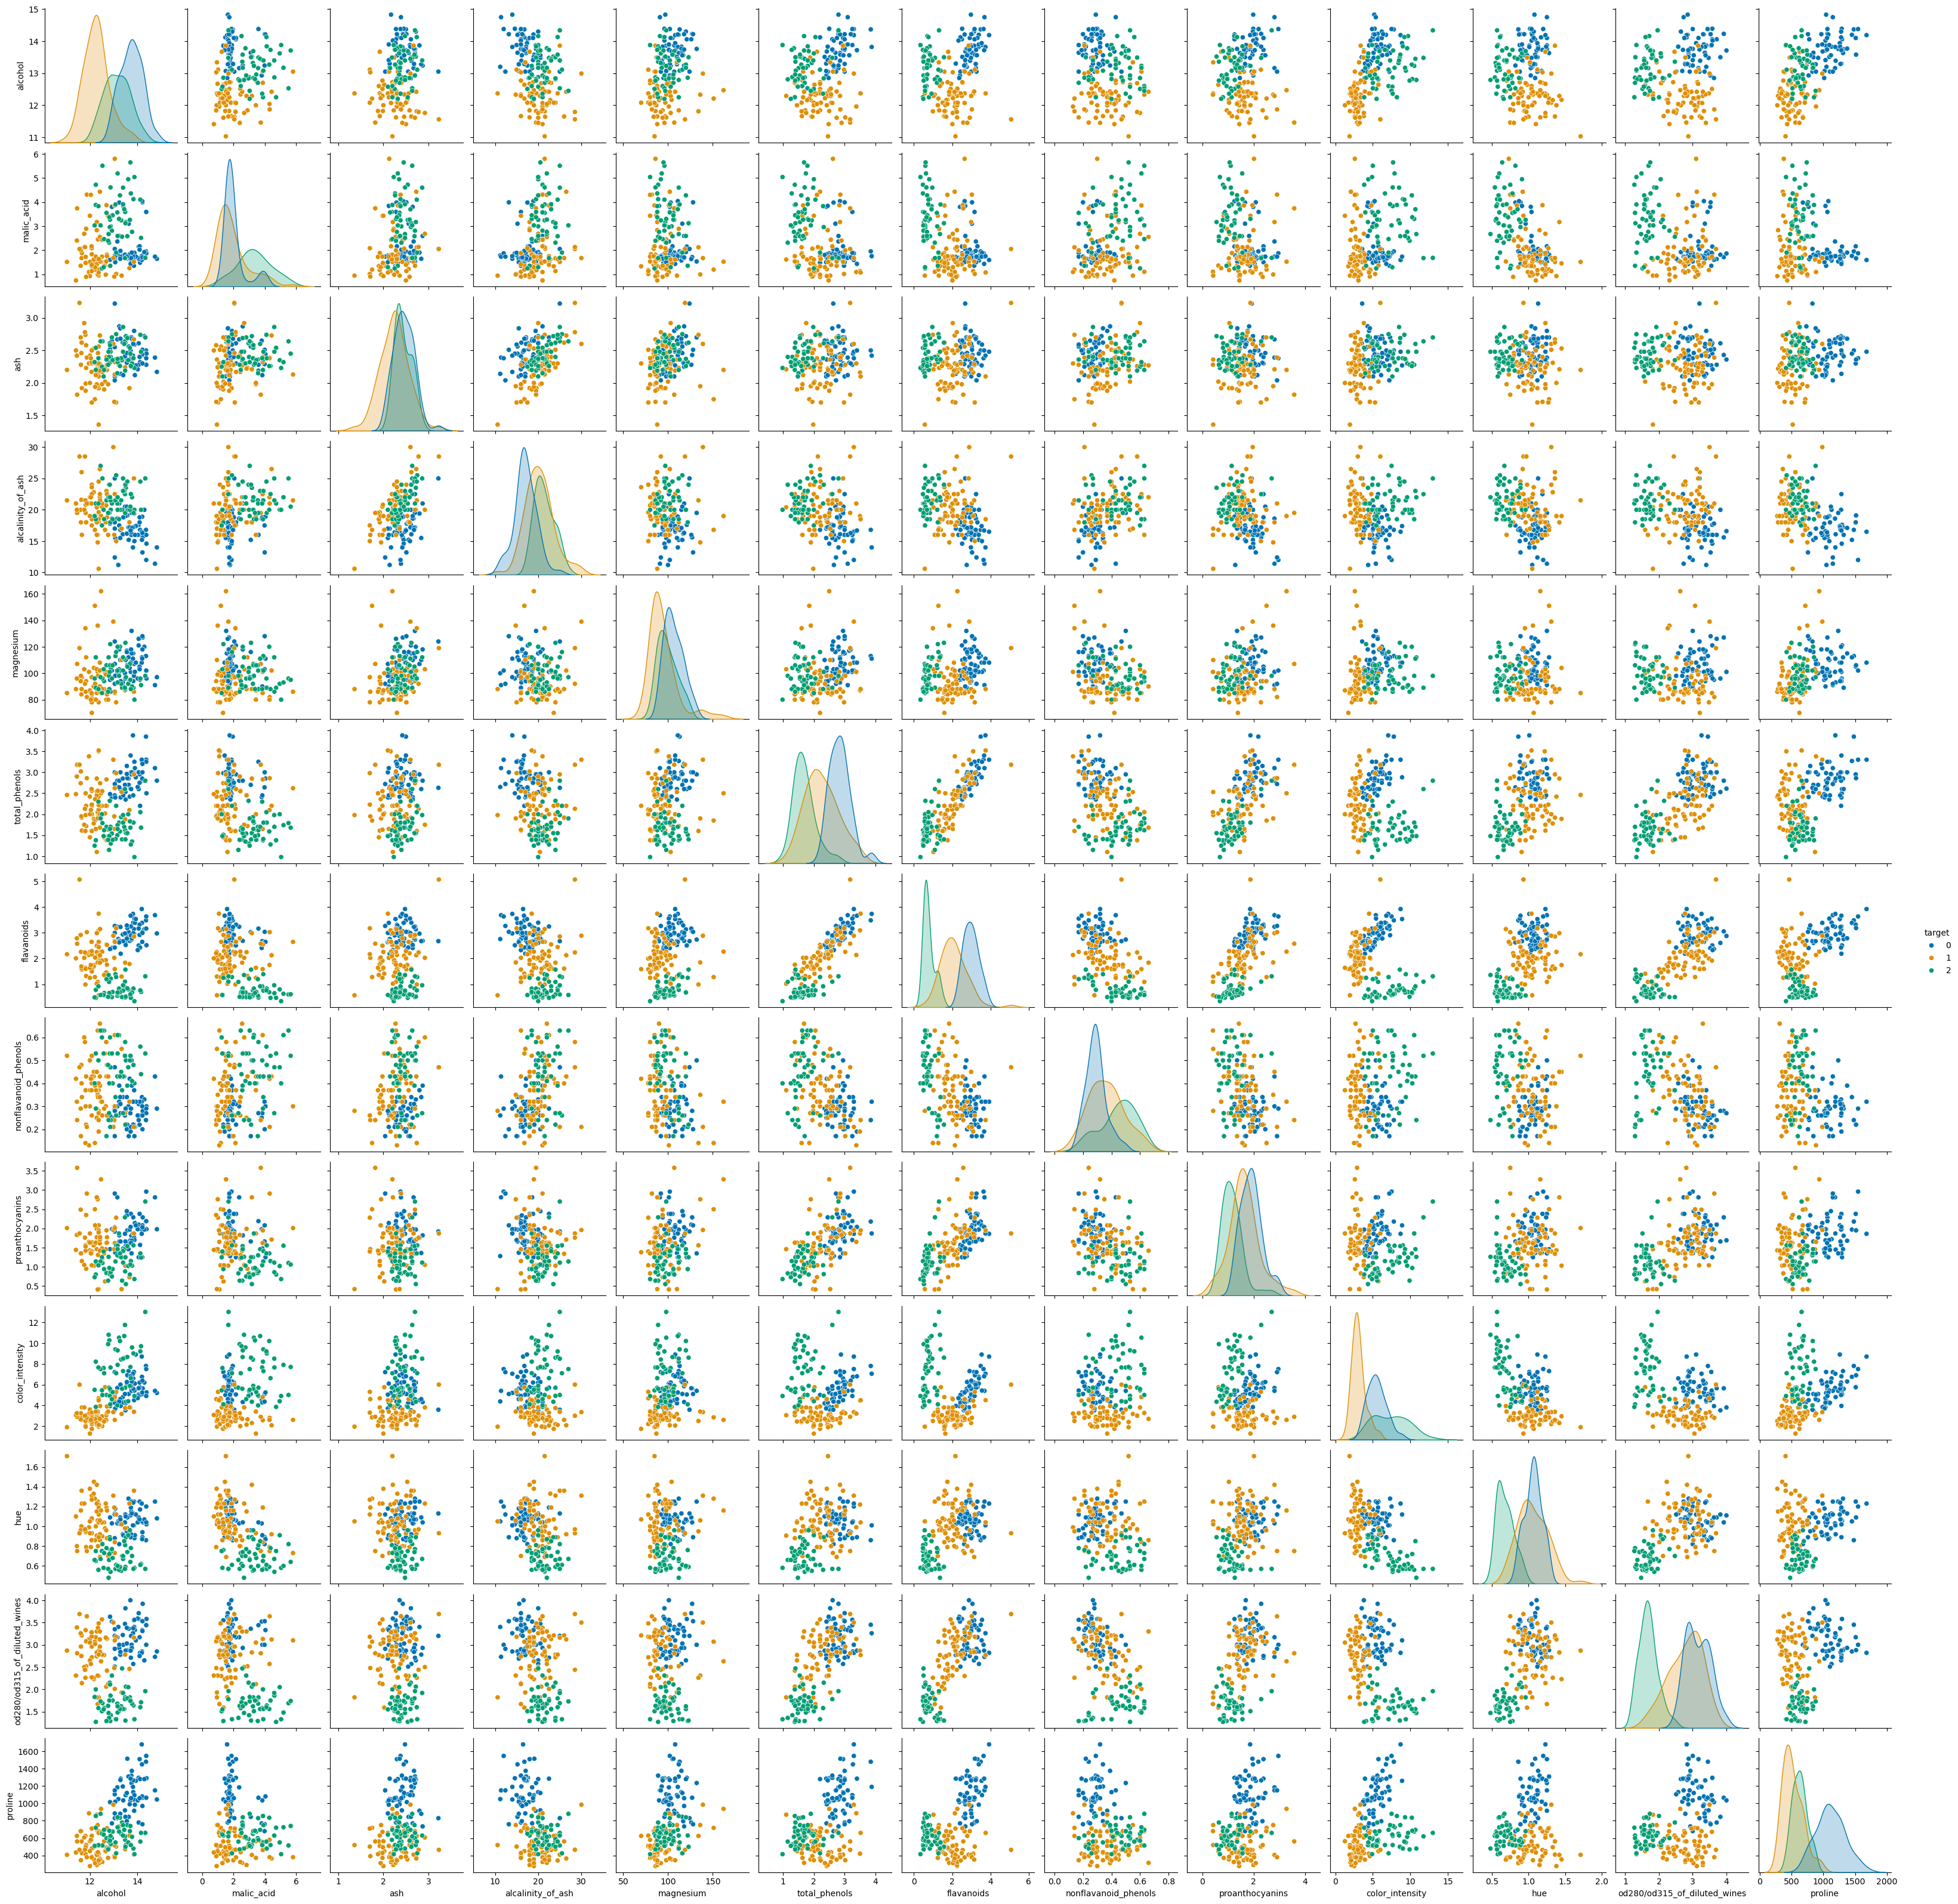

In [444]:
scatter_matrix_sns = sns.pairplot(data=frame, hue='target', palette='colorblind')

**DataFrame.corr()** can be called to numerically assess the correlation of each feature with one another, and with the target classes.

In [445]:
frame.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


From the correlation matrix, the features with the strongest correlation with the target are:
1. 'flavanoids' (-0.847498)
2. 'od280/od315_of_diluted_wines' (-0.788230)
3. 'total_phenols' (-0.719163)

Between the features themselves, the strongest correlations are:
1. 'total_phenols' with 'flavanoids' (0.864564)
2. 'flavanoids' with 'od280/od315_of_diluted_wines' (0.787194)
3. 'total_phenols' with 'od280/od315_of_diluted_wines' (0.699949)

Next, a K-Nearest Neighbors classifier will be used to classify the data based on the 13 features. 

First, the data must be split into a training set (67%) and test set (33%). This is done using *sklearn's* **train_test_split()** function. 

A random state is specified to ensure that the set does not change with every run.

In [446]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

The proportion of each class in the training set must be roughly equal to ensure that the classifier is not overfit to one specific class.

In [447]:
y_train.value_counts(normalize=True)

target
1    0.394958
0    0.327731
2    0.277311
Name: proportion, dtype: float64

The classifier is constructed using *sklearn's* **Pipeline** class. This is done because the features must first be scaled for the KNN classifier to work as intended. The **StandardScaler** class is used in this case.

Then, the **KNeighborsClassifier** class is used as the actual classifier. An 'n_neighbors' value of 11 was chosen (rather than the default value of 5) through manual trial, as it minimized the errors in the confusion matrix below.

In [448]:
clf = Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=11))])

Next, the classifier is fit to the training set.

In [449]:
clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=11))])

After training, the classifier is used to make predictions on the test set.

In [450]:
y_pred = clf.predict(X_test)

Then, the accuracy of the classifier on the test set is visualized using a confusion matrix.

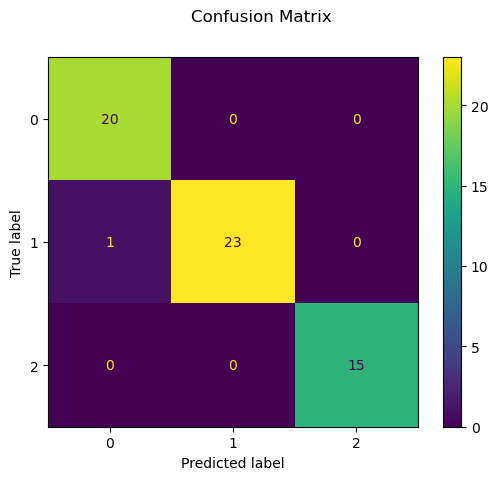

In [451]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
title_text = disp.figure_.suptitle("Confusion Matrix")
disp.ax_.grid(False)

The classifier appears to be well-trained, as evidenced by the high frequency along the diagonal. This indicates that the classifier is able to correctly identify each class equally well, making only a single mistake on the test set.

This can be further verified by calculating the classifier's accuracy, precision, recall, and F1. Macro averaging is used for precision, recall, and F1 as the classifier is nonbinary.

In [452]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}\n" 
      + f"Precision: {precision_score(y_test, y_pred, average='macro')}\n"
      + f"Recall: {recall_score(y_test, y_pred, average='macro')}\n"
      + f"F1: {f1_score(y_pred, y_test, average='macro')}")

Accuracy: 0.9830508474576272
Precision: 0.9841269841269842
Recall: 0.9861111111111112
F1: 0.9847777201176267


The classifier scores strongly in all areas, again showing its effectiveness.